# Create and evaluate SemIf Qwen3.5-4B in MLX 4-bit

This lesson explains the complete local pipeline: install the pinned runtime, convert the source checkpoint, verify the saved export, compare it with the unquantized MLX baseline, and run a new decision request. All substantial computation runs on an Apple Silicon Mac. The recorded run uses a Mac mini M4 with 16 GiB unified memory.

SemIf uses Qwen3.5-4B with a particular prompt and option-logit readout. This conversion adds no fine-tuning. It saves text-only MLX affine 4-bit weights, with group size 64; the vision tower is excluded. **The baseline contains BF16 and FP32 parameters, not an FP32-only model.**

By default the notebook reads the completed conversion and benchmark artifacts. Enable the two execution switches below to reproduce the expensive steps. Existing outputs are never overwritten by those scripts.

## 1. Install the environment

From this directory on the Mac mini, run:
```bash
python3.12 -m venv .venv
source .venv/bin/activate
python -m pip install -r requirements.txt
python -m pip install --no-deps \
  'git+https://github.com/TheoLeeCJ/SemIf.git@1f2dea3e25379f9dfc98cb83c324f00ab5deda37' \
  'git+https://github.com/fstandhartinger/jevbench.git@75e6224ed8103bbc3485ca74820a2eaf7ce8abe0'
python -m ipykernel install --prefix .venv --name semif-mlx --display-name 'Python (SemIf MLX)'
```
Select that kernel before running this notebook. Reuse a compatible environment already installed on the Mac mini instead of copying an environment from another machine. Model downloads and weights stay under ignored artifact/cache directories.

In [1]:
import json
import subprocess
import sys
from importlib.metadata import version
from pathlib import Path
from types import SimpleNamespace

from IPython.display import Image, display

ROOT = Path.cwd().resolve()
assert (ROOT / 'create_model.py').is_file(), 'Run from 2-best_model_card.'
MODEL = ROOT / 'artifacts/semif-4b-mlx-4bit'
RESULTS = ROOT / 'results/paired'
RUN_CONVERSION = False
RUN_BENCHMARK = False
# Optionally set a cached, pinned HF snapshot path to avoid downloading again.
SOURCE = None
print({name: version(name) for name in ('mlx', 'mlx-lm', 'transformers')})


{'mlx': '0.32.2', 'mlx-lm': '0.32.0', 'transformers': '5.17.0'}


## 2. Create the quantized checkpoint

`create_model.py` downloads the pinned Qwen source, loads the text backbone, quantizes eligible parameters and saves standard MLX files. It then releases the model, reloads the files and compares probabilities on four fixed synthetic cases. This tests persistence, not retained task accuracy.

Set `RUN_CONVERSION=True` for a fresh conversion. Choose a new `MODEL` directory if one already exists. To reuse downloaded weights, set `SOURCE` to the pinned Hugging Face snapshot. This directory must be named `851bf6e806efd8d0a36b00ddf55e13ccb7b8cd0a`.

In [2]:
source_args = ['--source', str(SOURCE)] if SOURCE else []
if RUN_CONVERSION:
    subprocess.run([sys.executable, 'create_model.py', '--output', str(MODEL), *source_args],
                   cwd=ROOT, check=True)
manifest_path = MODEL / 'decision_manifest.json'
assert manifest_path.is_file(), 'Run conversion first or set MODEL to an existing export.'
manifest = json.loads(manifest_path.read_text())
assert manifest['system'] == 'semif' and manifest['text_only']
assert manifest['quantization']['bits'] == 4
assert manifest['quantization']['group_size'] == 64
print('Source revision:', manifest['base_revision'])
print('Source dtypes:', manifest['baseline_dtypes'])
print('Reload probability difference:', manifest['reload_max_probability_error'])
print('Weight file GiB:', (MODEL / 'model.safetensors').stat().st_size / 2**30)


Source revision: 851bf6e806efd8d0a36b00ddf55e13ccb7b8cd0a
Source dtypes: ['mlx.core.bfloat16', 'mlx.core.float32']
Reload probability difference: 0.0
Weight file GiB: 2.2046685041859746


## 3. Verify the persisted artifact

The verifier checks file hashes and loads the exported quantized model in a separate process. It tests choice, affirmative/negative propositions and ordered scoring. A nonzero exit code stops the notebook. Four passing examples show basic functionality; they are not a scientific accuracy estimate.

In [3]:
subprocess.run([sys.executable, 'verify_decision_exports.py', '--system', 'semif',
                '--export', str(MODEL), '--output', str(ROOT / 'results/notebook-verification')],
               cwd=ROOT, check=True)


semif: damaged-parcel: PASS {'damaged': 0.9997694932780068, 'intact': 0.0002305067219931397}


semif: explicit-yes: PASS {'yes': 0.9982992775885648, 'no': 0.001700722411435288}


semif: explicit-no: PASS {'yes': 0.033085978388704126, 'no': 0.9669140216112958}


semif: high-satisfaction: PASS {'0': 0.09850568577644736, '1': 0.07671630521968295, '2': 0.8247780090038697}


CompletedProcess(args=['/Users/marco/GitHub/LLM-crash-course/21-openjev/1-quantization/.venv/bin/python', 'verify_decision_exports.py', '--system', 'semif', '--export', '/Users/marco/GitHub/LLM-crash-course/21-openjev/2-best_model_card/artifacts/semif-4b-mlx-4bit', '--output', '/Users/marco/GitHub/LLM-crash-course/21-openjev/2-best_model_card/results/notebook-verification'], returncode=0)

## 4. Compare source precision and 4-bit fairly

`benchmark.py` runs both variants in isolated sequential processes: first unquantized MLX, then the reloaded 4-bit model. They receive the same 231 public JevBench decisions and the same author prompt/readout. The script asserts identical prompt and token hashes. Labels never enter inference requests.

This is an **evaluation-only public benchmark**, not a train/validation/test experiment. No training split is used or fitted here; the source model's training belongs to Qwen. Public JevBench was used in upstream development and is not a held-out test. The independent synthetic cases above are runtime checks, not a validation set used for tuning. A separate held-out study is needed for stronger retention claims.

Set `RUN_BENCHMARK=True` and choose a fresh `RESULTS` directory to reproduce the full run. For a short pipeline check, add `--samples 8`, label those results accordingly, and do not confuse them with all 231 items. Timing includes tokenization and synchronized inference, excludes loading/warmup, and uses batch size one.

In [4]:
if RUN_BENCHMARK:
    subprocess.run([sys.executable, 'benchmark.py', '--model', str(MODEL),
                    '--output', str(RESULTS), *source_args], cwd=ROOT, check=True)
assert (RESULTS / 'summary.json').is_file(), 'Run benchmark.py first or enable RUN_BENCHMARK.'
protocol = json.loads((RESULTS / 'protocol.json').read_text())
assert protocol['export_manifest']['files_sha256']['model.safetensors'] == manifest['files_sha256']['model.safetensors']
summary = json.loads((RESULTS / 'summary.json').read_text())
for row in summary['measured']:
    print(f"{row['variant']}: {row['correct']}/{row['total']} = {row['accuracy_percent']:.2f}%; "
          f"median {row['median_latency_ms']:.1f} ms; peak MLX {row['peak_mlx_gib']:.3f} GiB")
print('Quantized minus baseline (pp):', summary['paired']['quantized_minus_baseline_pp'])
print('Paired bootstrap 95% interval (pp):', summary['paired']['paired_bootstrap_95_pp'])


baseline: 186/231 = 80.52%; median 694.1 ms; peak MLX 8.997 GiB
quantized: 180/231 = 77.92%; median 566.1 ms; peak MLX 3.370 GiB
Quantized minus baseline (pp): -2.5974025974025974
Paired bootstrap 95% interval (pp): [-6.926406926406926, 1.7316017316017316]


## 5. Read the chart and changed answers

Accuracy measures correct decisions. Latency and peak MLX allocation describe this workload and machine; parameter file size is a different quantity. MLX allocation and process RSS overlap and must not be added. The paired interval resamples examples and treats related public items as independent, so it is descriptive.

Regressions were correct before quantization and wrong afterward; improvements are the reverse. Equal totals can hide both. Keep these changes instead of selecting only successful examples.

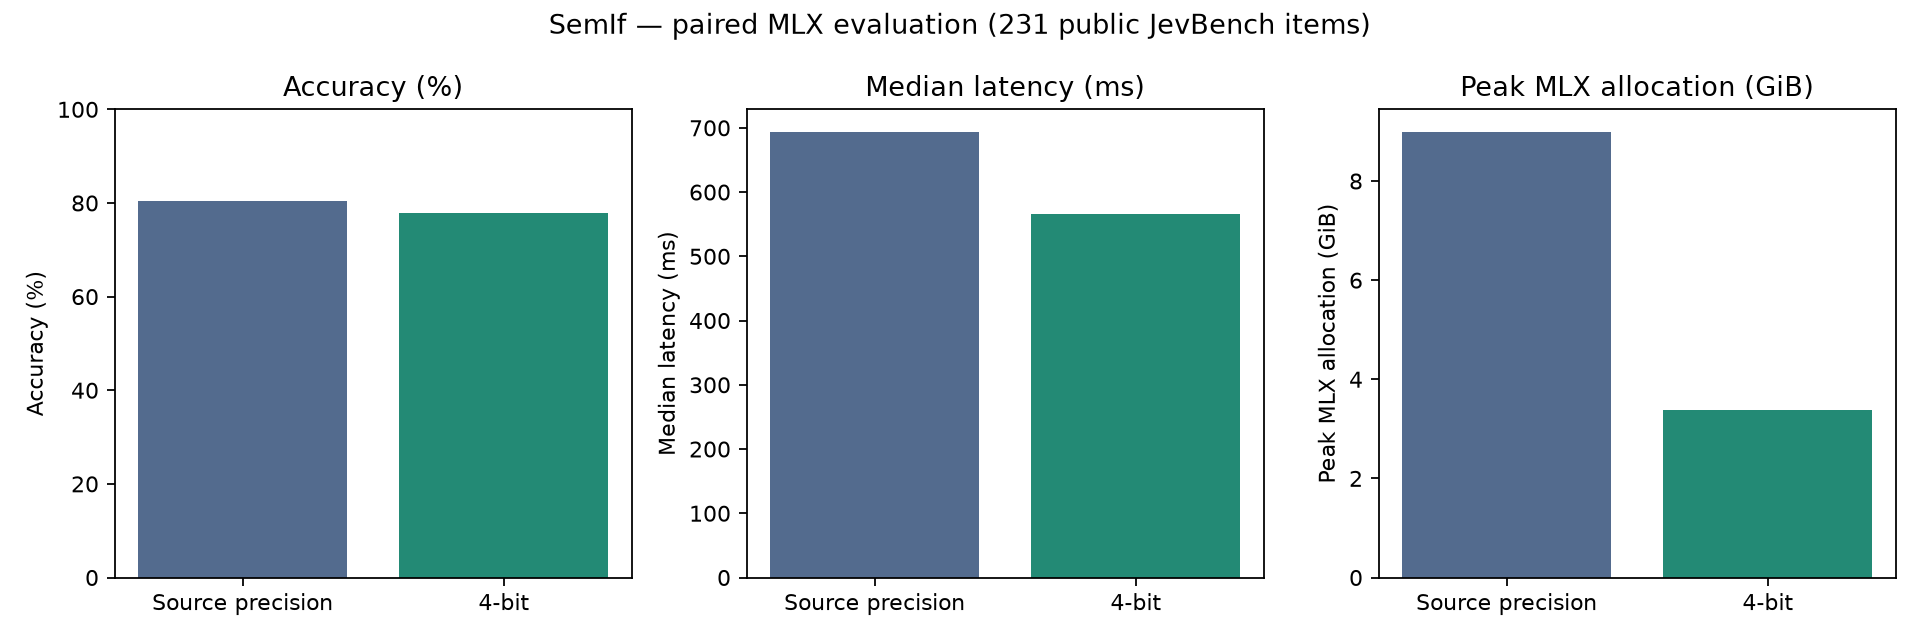

regressions: 15
['hard-sol-a-multi_hop-07', 'hard-opus-a-long_policy-08', 'hard-opus-a-long_policy-11', 'hard-opus-b-ambiguous-02', 'original-adequacy-03-1', 'hard-sol-b-long_policy-06', 'hard-opus-b-tradeoff-12', 'hard-opus-b-tradeoff-08', 'hard-opus-b-probability-01', 'original-policy-03-1', 'hard-opus-b-ambiguous-09', 'original-adequacy-03-0', 'hard-opus-b-tradeoff-01', 'hard-opus-a-temporal_numeric-03', 'hard-sol-a-multi_hop-08']
improvements: 9
['hard-sol-b-long_policy-01', 'hard-opus-b-multi_hop-04', 'hard-sol-c-judge_hard-09', 'hard-opus-b-multi_hop-07', 'hard-opus-c-long_policy-05', 'easy-fact-05', 'hard-opus-b-ambiguous-03', 'hard-opus-a-temporal_numeric-06', 'hard-opus-c-temporal_numeric-08']


In [5]:
display(Image(filename=str(RESULTS / 'comparison.png')))
for category in ('regressions', 'improvements'):
    ids = summary['paired'][category]
    print(f'{category}: {len(ids)}')
    print(ids)


## 6. Load the saved model and make a new request

The model returns a normalized distribution over supplied alternatives, not generated chat text. This new example is separate from the four fixed verification cases. Confidence is not a guarantee of truth. The loader uses the exact export inspected above.

In [6]:
from mlx_lm import load
from decision_mlx import configure, predict

configure()
model, tokenizer = load(MODEL, tokenizer_config={'trust_remote_code': False})
task = SimpleNamespace(
    id='new-delivery-example',
    state='The customer says the delivery arrived two days after the promised date.',
    question={'type': 'choice', 'instructions': 'Which delivery issue is explicitly reported?',
              'criteria': {'late': 'The delivery arrived later than promised.',
                           'damaged': 'The delivered item was broken.',
                           'missing': 'The delivery never arrived.'}},
)
probabilities, metadata = predict(model, tokenizer, 'semif', task)
print(probabilities)
print('Selected option:', max(probabilities, key=probabilities.get))
assert abs(sum(probabilities.values()) - 1) < 1e-5


/Users/marco/GitHub/LLM-crash-course/21-openjev/1-quantization/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'late': 0.999919210820175, 'damaged': 6.605117137757907e-05, 'missing': 1.4738008447470603e-05}
Selected option: late


## 7. Keep the evidence with the model

Keep the exported weights, manifest, pinned dependencies, runtime code and raw benchmark predictions together. The single README serves as the GitHub/Hugging Face card. For a Hub repository with weights at its root, use that root as the model path. Preserve Qwen and SemIf license notices.

This MLX artifact is not a tested Ollama export. A separate supported conversion and evaluation would be required. Historical Torch/MPS scores and this MLX comparison must not be presented as Ollama scores. No remote publication is performed here.